In [1]:
import numpy as np
import tensorflow as tf

# Load saved model
model1 = tf.keras.models.load_model("../models/model1_multivariate_lstm.keras")

# Load test data
X1_test = np.load("../models/X1_test.npy")
y1_test = np.load("../models/y1_test.npy")

print("Model loaded successfully.")


Model loaded successfully.


In [2]:
y1_pred = model1.predict(X1_test)

print("Prediction shape:", y1_pred.shape)


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 11 and 9 for '{{node sequential_1_1/lstm_10_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1_1/lstm_10_1/strided_slice_1, sequential_1_1/lstm_10_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [32,11], [9,256].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(32, 11), dtype=float32)
  • states=('tf.Tensor(shape=(32, 64), dtype=float32)', 'tf.Tensor(shape=(32, 64), dtype=float32)')
  • training=False

In [3]:
sample_index = 0

pred = y1_pred[sample_index]
true = y1_test[sample_index]

print("Predicted (scaled):")
print(pred)

print("\nActual (scaled):")
print(true)


Predicted (scaled):
[[0.6568509  0.6660463  0.4115248  0.44579905]
 [0.634115   0.65389633 0.41834143 0.35046706]
 [0.5624054  0.6545319  0.5093515  0.3662962 ]
 [0.5618084  0.655667   0.4979313  0.36136004]
 [0.56006813 0.65780836 0.4917512  0.3549752 ]
 [0.551934   0.6572351  0.49437624 0.35195652]]

Actual (scaled):
[[0.7596841  0.7030635  0.4495016  0.43035117]
 [0.7837728  0.59835345 0.57125384 0.29907888]
 [0.75830394 0.6587074  0.55823386 0.3695383 ]
 [0.690758   0.64540994 0.6169695  0.4497669 ]
 [0.5979764  0.65115184 0.5295531  0.49557662]
 [0.5331886  0.5724362  0.5103446  0.42267594]]


In [ ]:
import numpy as np

params = ["DO", "Temperature", "pH", "Turbidity"]

mae_per_param = np.mean(np.abs(y1_test - y1_pred), axis=(0,1))

for p, v in zip(params, mae_per_param):
    print(p, "MAE:", v)

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Flatten across samples and horizons
y_true = y1_test.reshape(-1, 4)
y_pred = y1_pred.reshape(-1, 4)

# Parameter names
params = ["DO", "Temperature", "pH", "Turbidity"]

for i, param in enumerate(params):
    mse = mean_squared_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    
    print(f"\n{param}")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)



DO
MSE: 0.014212165027856827
RMSE: 0.11921478527371018
MAE: 0.09635552763938904
R2: 0.14851713180541992

Temperature
MSE: 0.0077023981139063835
RMSE: 0.08776330733231505
MAE: 0.07077614963054657
R2: 0.12217134237289429

pH
MSE: 0.018845222890377045
RMSE: 0.13727790386794608
MAE: 0.11051616072654724
R2: 0.12364989519119263

Turbidity
MSE: 0.009131437167525291
RMSE: 0.09555855360733173
MAE: 0.07662966847419739
R2: 0.1352304220199585


In [6]:
for step in range(6):
    mse = mean_squared_error(y1_test[:, step, :], y1_pred[:, step, :])
    rmse = np.sqrt(mse)
    print(f"Horizon t+{step+1} RMSE:", rmse)


Horizon t+1 RMSE: 0.0779009586814205
Horizon t+2 RMSE: 0.10295670243493073
Horizon t+3 RMSE: 0.12033804306519148
Horizon t+4 RMSE: 0.12061209409485131
Horizon t+5 RMSE: 0.12060451507191303
Horizon t+6 RMSE: 0.12080627203807978


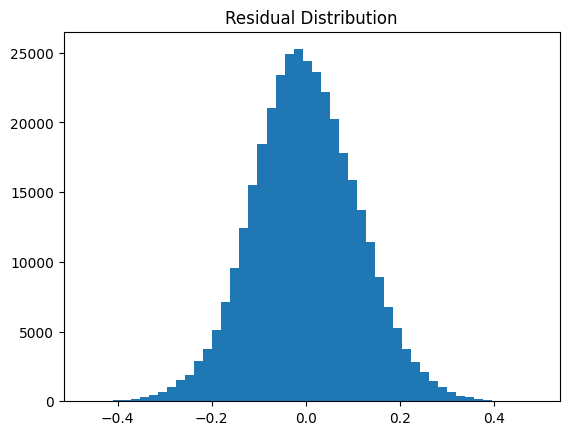

In [7]:
residuals = y_true - y_pred

import matplotlib.pyplot as plt
plt.hist(residuals.flatten(), bins=50)
plt.title("Residual Distribution")
plt.show()


In [4]:
# Get feature count
num_features = df_scaled.shape[1]

# Create empty array for inverse scaling
dummy = np.zeros((6, num_features))

# Get indices of model1 target columns
target_indices = [df_scaled.columns.get_loc(col) for col in model1_targets]

# Put predictions into correct column positions
dummy[:, target_indices] = pred

# Inverse transform
inv_pred = scaler.inverse_transform(dummy)

# Extract only target columns
inv_pred_targets = inv_pred[:, target_indices]

print("Predicted (original scale):")
print(inv_pred_targets)


NameError: name 'df_scaled' is not defined

In [ ]:
import pandas as pd

future_steps = [f"t+{i+1}" for i in range(6)]

pred_df = pd.DataFrame(
    inv_pred_targets,
    index=future_steps,
    columns=model1_targets
)

print(pred_df)


In [ ]:
model2 = tf.keras.models.load_model("../models/model2_nitrogen_lstm.keras")

X2_test = np.load("../models/X2_test.npy")
y2_test = np.load("../models/y2_test.npy")

y2_pred = model1.predict(X2_test)


print("Prediction shape:", y2_pred.shape)

sample_index = 0

pred = y2_pred[sample_index]
true = y2_test[sample_index]

print("Predicted (scaled):")
print(pred)

print("\nActual (scaled):")
print(true)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Flatten across samples and horizons
y_true = y2_test.reshape(-1, 4)
y_pred = y2_pred.reshape(-1, 4)

# Parameter names
params = ["DO", "Temperature", "pH", "Turbidity"]

for i, param in enumerate(params):
    mse = mean_squared_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    
    print(f"\n{param}")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
